In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import chi2_contingency


In [34]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [35]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 7043
Columns: 21


In [36]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [37]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [38]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [39]:
print(df["TotalCharges"].head(20))
blank_total_charges = df["TotalCharges"].str.strip().eq("").sum()

print("Blank TotalCharges:", blank_total_charges)

0       29.85
1      1889.5
2      108.15
3     1840.75
4      151.65
5       820.5
6      1949.4
7       301.9
8     3046.05
9     3487.95
10     587.45
11      326.8
12     5681.1
13     5036.3
14    2686.05
15    7895.15
16    1022.95
17    7382.25
18     528.35
19     1862.9
Name: TotalCharges, dtype: str
Blank TotalCharges: 11


In [40]:
total_charges_numeric = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)
print("Values that cannot be converted:", total_charges_numeric.isna().sum())

Values that cannot be converted: 11


In [41]:
print(df["Churn"].value_counts())
print()
print(df["Churn"].value_counts(normalize=True) * 100)

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [42]:
categorical_columns = df.select_dtypes(include="str").columns

for col in categorical_columns:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())


--- customerID ---
customerID
7590-VHVEG    1
5575-GNVDE    1
3668-QPYBK    1
7795-CFOCW    1
9237-HQITU    1
             ..
6840-RESVB    1
2234-XADUH    1
4801-JZAZL    1
8361-LTMKD    1
3186-AJIEK    1
Name: count, Length: 7043, dtype: int64

--- gender ---
gender
Male      3555
Female    3488
Name: count, dtype: int64

--- Partner ---
Partner
No     3641
Yes    3402
Name: count, dtype: int64

--- Dependents ---
Dependents
No     4933
Yes    2110
Name: count, dtype: int64

--- PhoneService ---
PhoneService
Yes    6361
No      682
Name: count, dtype: int64

--- MultipleLines ---
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

--- InternetService ---
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

--- OnlineSecurity ---
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

--- OnlineBackup -

In [43]:
df[df["TotalCharges"].str.strip() == ""]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [44]:
df[df["TotalCharges"].str.strip() == ""][
    ["customerID", "tenure", "MonthlyCharges", "Contract", "Churn"]
]

,customerID,tenure,MonthlyCharges,Contract,Churn
488,4472-LVYGI,0,52.55,Two year,No
753,3115-CZMZD,0,20.25,Two year,No
936,5709-LVOEQ,0,80.85,Two year,No
1082,4367-NUYAO,0,25.75,Two year,No
1340,1371-DWPAZ,0,56.05,Two year,No
3331,7644-OMVMY,0,19.85,Two year,No
3826,3213-VVOLG,0,25.35,Two year,No
4380,2520-SGTTA,0,20.00,Two year,No
5218,2923-ARZLG,0,19.70,One year,No
6670,4075-WKNIU,0,73.35,Two year,No


In [45]:
df[df["TotalCharges"].str.strip() == ""].describe()

,SeniorCitizen,tenure,MonthlyCharges
count,11.0,11.0,11.000000
mean,0.0,0.0,41.418182
std,0.0,0.0,23.831484
min,0.0,0.0,19.700000
25%,0.0,0.0,20.125000
50%,0.0,0.0,25.750000
75%,0.0,0.0,58.975000
max,0.0,0.0,80.850000


In [46]:
df[df["TotalCharges"].str.strip() == ""]["Churn"].value_counts()

Churn
No    11
Name: count, dtype: int64

In [47]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [48]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)

In [49]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate customer IDs:", df["customerID"].duplicated().sum())

Duplicate rows: 0
Duplicate customer IDs: 0


In [50]:
df[["SeniorCitizen", "tenure", "MonthlyCharges"]].describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [51]:
print("Negative tenure:", (df["tenure"] < 0).sum())
print("Negative MonthlyCharges:", (df["MonthlyCharges"] < 0).sum())

Negative tenure: 0
Negative MonthlyCharges: 0


In [52]:
print("Minimum tenure:", df["tenure"].min())
print("Maximum tenure:", df["tenure"].max())

print("Minimum MonthlyCharges:", df["MonthlyCharges"].min())
print("Maximum MonthlyCharges:", df["MonthlyCharges"].max())

Minimum tenure: 0
Maximum tenure: 72
Minimum MonthlyCharges: 18.25
Maximum MonthlyCharges: 118.75


In [53]:
print(df["TotalCharges"].dtype)
print(df["TotalCharges"].isna().sum())

float64
0


In [54]:
df["ChurnFlag"] = (df["Churn"] == "Yes").astype(int)

In [55]:
df["ChurnFlag"].value_counts()

ChurnFlag
0    5174
1    1869
Name: count, dtype: int64

Does churn differ significantly depending on the customer's contract type?

In [56]:
total_customers = len(df)

churned_customers = (df["Churn"] == "Yes").sum()
retained_customers = (df["Churn"] == "No").sum()

churn_rate = churned_customers / total_customers * 100

print("Total Customers:", total_customers)
print("Churned Customers:", churned_customers)
print("Retained Customers:", retained_customers)
print("Churn Rate:", round(churn_rate, 2), "%")

Total Customers: 7043
Churned Customers: 1869
Retained Customers: 5174
Churn Rate: 26.54 %


In [57]:
contract_churn = (
    df.groupby("Contract")["ChurnFlag"]
      .agg(["count", "sum", "mean"])
      .reset_index()
)

contract_churn.columns = [
    "Contract",
    "Customers",
    "Churned",
    "ChurnRate"
]

contract_churn["ChurnRate"] = (
    contract_churn["ChurnRate"] * 100
).round(2)

contract_churn.sort_values(
    "ChurnRate",
    ascending=False
)

,Contract,Customers,Churned,ChurnRate
0,Month-to-month,3875,1655,42.71
1,One year,1473,166,11.27
2,Two year,1695,48,2.83


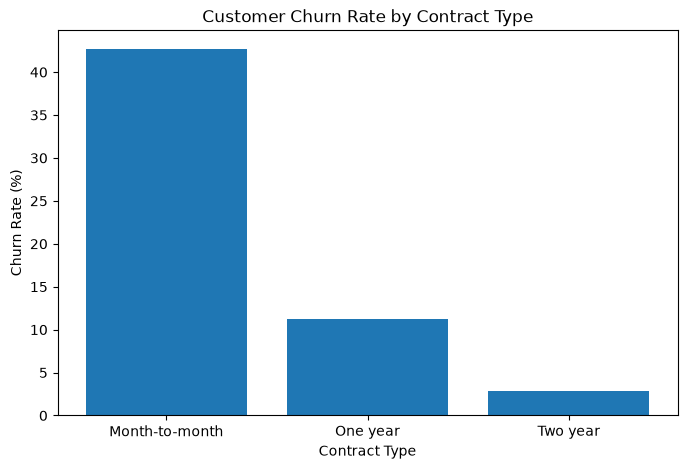

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    contract_churn["Contract"],
    contract_churn["ChurnRate"]
)

plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.title("Customer Churn Rate by Contract Type")

plt.show()

In [59]:
contract_table = pd.crosstab(
    df["Contract"],
    df["Churn"]
)

contract_table

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


In [61]:
#Chi-square test of independence

#Hypotheses

# H₀: Contract type and churn are independent

# H₁: Contract type and churn are associated

chi2, p_value, dof, expected = chi2_contingency(
    contract_table
)

print("Chi-square statistic:", chi2)
print("p-value:", p_value)
print("Degrees of freedom:", dof)

Chi-square statistic: 1184.5965720837926
p-value: 5.863038300673391e-258
Degrees of freedom: 2


In [62]:
contract_table = pd.crosstab(df["Contract"], df["Churn"])

contract_table["ChurnRate"] = (
    contract_table["Yes"] /
    contract_table.sum(axis=1) * 100
).round(2)

contract_table

Churn,No,Yes,ChurnRate
Contract,,,
Month-to-month,2220,1655,42.71
One year,1307,166,11.27
Two year,1647,48,2.83


In [63]:
# assuming a 5% signicance level, we can reject the null hypothesis if the p-value is less than 0.05. 
# In this case, if the p-value is less than 0.05, we conclude that there is a significant association between contract type and churn.

if p_value < 0.05:
    print("Reject the null hypothesis. There is a significant association between contract type and churn.")
else:
    print("Fail to reject the null hypothesis. There is no significant association between contract type and churn.")

Reject the null hypothesis. There is a significant association between contract type and churn.


In [ ]:
chi2, p_value, dof, expected = chi2_contingency(
    pd.crosstab(df["Contract"], df["Churn"])
)

n = pd.crosstab(df["Contract"], df["Churn"]).values.sum()
r, k = pd.crosstab(df["Contract"], df["Churn"]).shape

cramers_v = np.sqrt(
    chi2 / (n * min(k - 1, r - 1))
)

print("Chi-square:", chi2)
print("p-value:", p_value)
print("Cramer's V:", round(cramers_v, 3))

Chi-square: 1184.5965720837926
p-value: 5.863038300673391e-258
Cramer's V: 0.41


WHEN are customers most vulnerable to leaving?

In [66]:
df.groupby("Churn")["tenure"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,37.569965,24.113777,0.0,15.0,38.0,61.0,72.0
Yes,1869.0,17.979133,19.531123,1.0,2.0,10.0,29.0,72.0


In [67]:
df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=[-1, 6, 12, 24, 48, 72],
    labels=[
        "0-6 months",
        "7-12 months",
        "13-24 months",
        "25-48 months",
        "49-72 months"
    ]
)

In [68]:
tenure_churn = (
    df.groupby("TenureGroup", observed=True)["ChurnFlag"]
      .agg(["count", "sum", "mean"])
      .reset_index()
)

tenure_churn.columns = [
    "TenureGroup",
    "Customers",
    "Churned",
    "ChurnRate"
]

tenure_churn["ChurnRate"] = (
    tenure_churn["ChurnRate"] * 100
).round(2)

tenure_churn

,TenureGroup,Customers,Churned,ChurnRate
0,0-6 months,1481,784,52.94
1,7-12 months,705,253,35.89
2,13-24 months,1024,294,28.71
3,25-48 months,1594,325,20.39
4,49-72 months,2239,213,9.51


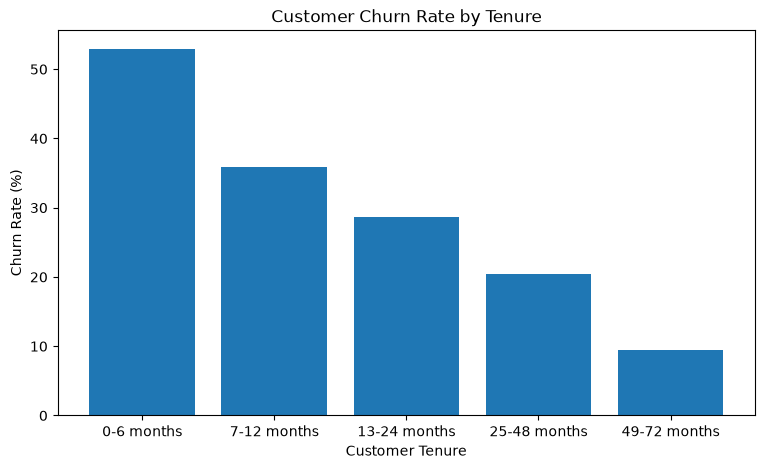

In [70]:
plt.figure(figsize=(9, 5))

plt.bar(
    tenure_churn["TenureGroup"].astype(str),
    tenure_churn["ChurnRate"]
)

plt.xlabel("Customer Tenure")
plt.ylabel("Churn Rate (%)")
plt.title("Customer Churn Rate by Tenure")

plt.show()

Is the average tenure of churned customers significantly different from that of retained customers?

In [78]:
#H₀:The mean tenure of churned customers equals the mean tenure of retained customers

# H₁:The mean tenure of churned customers is different from the mean tenure of retained customers

churned_tenure = df.loc[
    df["Churn"] == "Yes",
    "tenure"
]

retained_tenure = df.loc[
    df["Churn"] == "No",
    "tenure"
]

t_stat, p_value = stats.ttest_ind(
    churned_tenure,
    retained_tenure,
    equal_var=False,
    alternative = "two-sided"
)

print("T-statistic:", t_stat)
print("p-value:", p_value)

if p_value < 0.05:
    print("Reject the null hypothesis. The mean tenure of churned customers is different from the mean tenure of retained customers.")
else:
    print("Fail to reject the null hypothesis. The mean tenure of churned customers is not different from the mean tenure of retained customers.")

T-statistic: -34.823818696312976
p-value: 1.195494547260576e-232
Reject the null hypothesis. The mean tenure of churned customers is different from the mean tenure of retained customers.


In [80]:
#analysis of the results

#Customer tenure is strongly associated with churn. 
#Churned customers have substantially lower average tenure than retained customers (17.98 vs. 37.57 months), 
# and Welch's t-test indicates that the difference is statistically significant (t = −34.82, p < 0.001)

segmentation - Contract × Tenure × Churn

In [81]:
contract_tenure_churn = (
    df.groupby(
        ["Contract", "TenureGroup"],
        observed=True
    )["ChurnFlag"]
    .agg(["count", "sum", "mean"])
    .reset_index()
)

contract_tenure_churn.columns = [
    "Contract",
    "TenureGroup",
    "Customers",
    "Churned",
    "ChurnRate"
]

contract_tenure_churn["ChurnRate"] = (
    contract_tenure_churn["ChurnRate"] * 100
).round(2)

contract_tenure_churn

,Contract,TenureGroup,Customers,Churned,ChurnRate
0,Month-to-month,0-6 months,1413,780,55.20
1,Month-to-month,7-12 months,581,244,42.00
2,Month-to-month,13-24 months,737,278,37.72
3,Month-to-month,25-48 months,802,264,32.92
4,Month-to-month,49-72 months,342,89,26.02
5,One year,0-6 months,39,4,10.26
6,One year,7-12 months,85,9,10.59
7,One year,13-24 months,197,16,8.12
8,One year,25-48 months,518,55,10.62
9,One year,49-72 months,634,82,12.93


In [82]:
#analysis of the results

#Month-to-month customers exhibit elevated churn across every tenure band, 
# with the highest risk concentrated among customers in their first six months.

Are customers paying more each month also more likely to churn?

In [83]:
df.groupby("Churn")["MonthlyCharges"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,61.265124,31.092648,18.25,25.10,64.425,88.4,118.75
Yes,1869.0,74.441332,24.666053,18.85,56.15,79.650,94.2,118.35


In [84]:
monthly_charge_summary = (
    df.groupby("Churn")["MonthlyCharges"]
      .agg(["count", "mean", "median", "std"])
      .round(2)
)

monthly_charge_summary

,count,mean,median,std
Churn,,,,
No,5174,61.27,64.43,31.09
Yes,1869,74.44,79.65,24.67


In [85]:
df["MonthlyChargeGroup"] = pd.cut(
    df["MonthlyCharges"],
    bins=[0, 30, 60, 90, 120],
    labels=[
        "< $30",
        "$30–60",
        "$60–90",
        "$90+"
    ]
)

In [86]:
charge_churn = (
    df.groupby("MonthlyChargeGroup", observed=True)["ChurnFlag"]
      .agg(["count", "sum", "mean"])
      .reset_index()
)

charge_churn.columns = [
    "MonthlyChargeGroup",
    "Customers",
    "Churned",
    "ChurnRate"
]

charge_churn["ChurnRate"] = (
    charge_churn["ChurnRate"] * 100
).round(2)

charge_churn

,MonthlyChargeGroup,Customers,Churned,ChurnRate
0,< $30,1653,162,9.80
1,$30–60,1265,328,25.93
2,$60–90,2386,809,33.91
3,$90+,1739,570,32.78
